# Лабораторна робота № 2

## Оптимізаційна задача та аналіз чутливості

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Побудувати оптимізаційну модель у двох середовищах, прочитати звіт про стійкість
і **ухвалити на його основі господарське рішення**.

Розв'язати задачу — не мета. Solver зробить це за дві секунди. Робота оцінюється за
те, що ви зумієте зі звіту витягнути.

### Дві частини

| Частина | Задача | Де виконується |
|---|---|---|
| **1** | виробнича задача — Excel і Python | аудиторно |
| **2** | транспортна задача — Python | самостійно |

Друга частина потрібна не для повторення. Там та сама методика поводиться інакше,
і ви маєте побачити, де саме проходить межа її застосовності.

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Виконується згори донизу на чистому
   ядрі** (Kernel → Restart & Run All) без помилок — перевіряється першою дією на захисті.
2. Файл Excel з моделлю, налаштуваннями Solver і **звітом про стійкість** окремим аркушем.
3. Заповнена декларація про використання ШІ (етап 12).

### Оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Модель не сформульовано або розв'язок не отримано |
| 1 | Розв'язок отримано лише в одному середовищі, звіт про стійкість не проаналізовано |
| 2 | Задачу розв'язано в обох середовищах і звіти зіставлено, але тіньові ціни та діапазони не інтерпретовано |
| 4 | Звіт прочитано й перевірено експериментом, ухвалено обґрунтоване рішення про закупівлю, виконано частину 2 з поясненням розбіжності |

---
## Крок 0. Ваші дані та варіант

In [84]:
ПІБ = 'Кривичко Назар'        # напр. 'Шевченко Тарас'
ГРУПА = 'ШІ-34'      # напр. 'КН-31'
ВАРІАНТ = 11     # ваш номер за списком групи

assert ПІБ and ГРУПА and 1 <= ВАРІАНТ <= 30, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ (1..30)'

In [85]:
# --- клітинку не редагувати: вона видає дані вашого варіанта -----------------
import json, numpy as np, pandas as pd

ДАНІ_ВАРІАНТІВ = json.loads('''{"1": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[0, 2, 1, 1], [3, 3, 0, 6], [2, 3, 0, 2], [4, 6, 0, 5], [3, 1, 5, 4]], "c": [21, 69, 44, 39], "b": [929, 410, 507, 865, 425], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.2, "обсяг_пропозиції": 44}, "2": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 2, 5, 2], [6, 5, 4, 2], [5, 2, 0, 3], [2, 1, 5, 0], [5, 5, 6, 2]], "c": [40, 66, 24, 34], "b": [1271, 702, 915, 1388, 804], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.7, "обсяг_пропозиції": 204}, "3": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[5, 2, 6, 6], [3, 4, 3, 6], [1, 6, 6, 0], [3, 1, 6, 1], [4, 1, 1, 4]], "c": [51, 16, 34, 22], "b": [1189, 686, 1311, 512, 1030], "ресурс_пропозиції": 3, "ціна_пропозиції": 11.3, "обсяг_пропозиції": 348}, "4": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 0, 0, 0], [1, 0, 5, 2], [2, 4, 6, 5], [3, 0, 5, 3], [2, 1, 2, 5]], "c": [41, 50, 54, 26], "b": [815, 344, 840, 840, 382], "ресурс_пропозиції": 4, "ціна_пропозиції": 8.3, "обсяг_пропозиції": 144}, "5": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[3, 0, 6, 6], [3, 2, 2, 4], [5, 5, 0, 6], [2, 1, 5, 3], [5, 5, 4, 2]], "c": [32, 66, 25, 24], "b": [874, 1034, 1349, 845, 1394], "ресурс_пропозиції": 2, "ціна_пропозиції": 8.6, "обсяг_пропозиції": 90}, "6": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[3, 2, 1, 4], [4, 2, 2, 1], [3, 5, 1, 2], [3, 2, 0, 2], [6, 4, 6, 3]], "c": [40, 62, 19, 57], "b": [630, 391, 1349, 811, 1085], "ресурс_пропозиції": 1, "ціна_пропозиції": 29.5, "обсяг_пропозиції": 268}, "7": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[0, 0, 5, 5], [4, 4, 0, 1], [2, 4, 0, 6], [6, 3, 4, 1], [2, 2, 1, 0]], "c": [20, 59, 63, 41], "b": [1189, 1189, 1217, 915, 424], "ресурс_пропозиції": 3, "ціна_пропозиції": 8.0, "обсяг_пропозиції": 314}, "8": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[2, 1, 3, 5], [3, 1, 0, 6], [1, 6, 1, 5], [2, 2, 4, 0], [6, 1, 2, 2]], "c": [60, 25, 59, 25], "b": [1279, 761, 376, 1230, 1065], "ресурс_пропозиції": 3, "ціна_пропозиції": 9.5, "обсяг_пропозиції": 234}, "9": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 2, 1, 2], [5, 0, 1, 3], [5, 4, 6, 4], [4, 1, 1, 5], [6, 0, 3, 0]], "c": [58, 39, 54, 16], "b": [1147, 1199, 1280, 404, 1170], "ресурс_пропозиції": 2, "ціна_пропозиції": 6.1, "обсяг_пропозиції": 672}, "10": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 0, 4, 3], [0, 6, 0, 6], [5, 5, 3, 5], [6, 2, 3, 3], [3, 0, 0, 4]], "c": [20, 29, 37, 63], "b": [905, 344, 866, 1390, 355], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.3, "обсяг_пропозиції": 78}, "11": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 0, 3], [3, 1, 4, 0], [1, 0, 3, 2], [3, 2, 2, 6], [3, 6, 0, 3]], "c": [30, 16, 51, 35], "b": [1312, 838, 1062, 1038, 1236], "ресурс_пропозиції": 1, "ціна_пропозиції": 15.6, "обсяг_пропозиції": 778}, "12": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 2, 0, 5], [1, 1, 3, 6], [6, 3, 5, 4], [2, 4, 6, 0], [4, 6, 2, 4]], "c": [39, 55, 36, 26], "b": [788, 661, 458, 1005, 535], "ресурс_пропозиції": 4, "ціна_пропозиції": 5.0, "обсяг_пропозиції": 762}, "13": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[1, 5, 3, 0], [6, 4, 6, 3], [4, 4, 4, 1], [0, 3, 5, 3], [3, 5, 3, 3]], "c": [59, 42, 53, 19], "b": [937, 1390, 603, 1120, 1334], "ресурс_пропозиції": 2, "ціна_пропозиції": 15.1, "обсяг_пропозиції": 646}, "14": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 3, 3, 4], [6, 6, 1, 6], [1, 3, 5, 1], [1, 5, 1, 4], [4, 4, 0, 3]], "c": [26, 56, 41, 40], "b": [969, 672, 1364, 878, 618], "ресурс_пропозиції": 2, "ціна_пропозиції": 5.0, "обсяг_пропозиції": 222}, "15": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[5, 3, 3, 1], [2, 5, 6, 6], [3, 1, 0, 0], [0, 4, 4, 6], [2, 2, 2, 6]], "c": [64, 58, 34, 63], "b": [613, 316, 1035, 739, 810], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.4, "обсяг_пропозиції": 354}, "16": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[1, 6, 4, 2], [4, 1, 1, 2], [4, 4, 6, 6], [5, 6, 3, 3], [1, 2, 4, 2]], "c": [33, 40, 58, 17], "b": [412, 1005, 996, 599, 390], "ресурс_пропозиції": 4, "ціна_пропозиції": 8.2, "обсяг_пропозиції": 44}, "17": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[2, 6, 0, 3], [2, 5, 5, 3], [6, 0, 4, 5], [1, 3, 6, 2], [0, 1, 4, 4]], "c": [33, 52, 20, 66], "b": [989, 1079, 873, 1327, 1224], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.9, "обсяг_пропозиції": 402}, "18": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[2, 3, 0, 1], [0, 6, 1, 6], [1, 0, 4, 1], [2, 6, 3, 4], [3, 1, 6, 5]], "c": [66, 54, 18, 66], "b": [1217, 668, 923, 1040, 619], "ресурс_пропозиції": 4, "ціна_пропозиції": 34.9, "обсяг_пропозиції": 100}, "19": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 0, 2], [3, 3, 4, 5], [2, 1, 0, 4], [4, 1, 5, 0], [0, 3, 6, 3]], "c": [67, 52, 41, 40], "b": [315, 617, 815, 423, 1193], "ресурс_пропозиції": 1, "ціна_пропозиції": 9.3, "обсяг_пропозиції": 332}, "20": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 4, 5, 1], [2, 0, 5, 4], [4, 0, 2, 3], [3, 3, 4, 3], [4, 4, 5, 2]], "c": [42, 63, 35, 56], "b": [1191, 331, 685, 1275, 971], "ресурс_пропозиції": 4, "ціна_пропозиції": 12.2, "обсяг_пропозиції": 604}, "21": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 5, 3, 6], [4, 4, 3, 2], [4, 4, 4, 0], [1, 1, 5, 3], [0, 2, 6, 5]], "c": [32, 66, 26, 64], "b": [464, 393, 354, 597, 887], "ресурс_пропозиції": 0, "ціна_пропозиції": 9.4, "обсяг_пропозиції": 190}, "22": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[6, 0, 2, 6], [3, 4, 0, 4], [4, 3, 1, 5], [5, 5, 6, 2], [2, 0, 1, 5]], "c": [65, 36, 50, 63], "b": [891, 1247, 613, 1070, 1259], "ресурс_пропозиції": 2, "ціна_пропозиції": 13.6, "обсяг_пропозиції": 64}, "23": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[1, 2, 4, 6], [4, 6, 2, 5], [0, 5, 3, 1], [0, 0, 5, 1], [5, 4, 0, 5]], "c": [15, 35, 49, 23], "b": [1251, 637, 304, 629, 923], "ресурс_пропозиції": 2, "ціна_пропозиції": 10.9, "обсяг_пропозиції": 146}, "24": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[3, 2, 6, 1], [0, 2, 5, 6], [2, 4, 4, 0], [5, 6, 2, 5], [2, 4, 2, 1]], "c": [45, 61, 59, 38], "b": [927, 1384, 1294, 798, 323], "ресурс_пропозиції": 4, "ціна_пропозиції": 20.5, "обсяг_пропозиції": 110}, "25": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 5, 4, 4], [2, 1, 4, 1], [3, 1, 4, 4], [1, 4, 2, 0], [6, 4, 6, 6]], "c": [35, 27, 63, 61], "b": [1399, 843, 308, 1393, 713], "ресурс_пропозиції": 2, "ціна_пропозиції": 7.7, "обсяг_пропозиції": 334}, "26": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 1, 4, 4], [3, 1, 5, 0], [6, 3, 6, 3], [1, 3, 6, 1], [6, 4, 5, 2]], "c": [46, 57, 60, 39], "b": [513, 1330, 796, 406, 1258], "ресурс_пропозиції": 3, "ціна_пропозиції": 18.1, "обсяг_пропозиції": 448}, "27": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 6, 0], [6, 5, 6, 0], [5, 2, 3, 0], [6, 4, 3, 6], [6, 0, 0, 3]], "c": [24, 61, 50, 57], "b": [1179, 1358, 417, 463, 610], "ресурс_пропозиції": 3, "ціна_пропозиції": 9.0, "обсяг_пропозиції": 742}, "28": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[4, 5, 6, 2], [6, 4, 2, 1], [0, 5, 4, 3], [6, 6, 3, 3], [4, 4, 4, 1]], "c": [37, 41, 30, 29], "b": [514, 461, 378, 834, 488], "ресурс_пропозиції": 2, "ціна_пропозиції": 5.5, "обсяг_пропозиції": 174}, "29": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[3, 5, 0, 5], [6, 0, 6, 1], [5, 2, 2, 3], [0, 3, 0, 1], [4, 5, 5, 0]], "c": [33, 57, 58, 62], "b": [820, 523, 670, 977, 1074], "ресурс_пропозиції": 0, "ціна_пропозиції": 15.2, "обсяг_пропозиції": 570}, "30": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[2, 1, 4, 0], [6, 5, 1, 4], [5, 6, 1, 4], [1, 2, 6, 0], [1, 0, 3, 1]], "c": [51, 44, 69, 55], "b": [379, 620, 1256, 502, 414], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.9, "обсяг_пропозиції": 230}}''')

V = ДАНІ_ВАРІАНТІВ[str(ВАРІАНТ)]
A = np.array(V['A'], float)          # витрати ресурсу i на один виріб j
c = np.array(V['c'], float)          # прибуток з одного виробу
b = np.array(V['b'], float)          # запас ресурсу на плановий період
вироби, ресурси = V['вироби'], V['ресурси']

print('ВАРІАНТ %d · %s, %s, %s' % (ВАРІАНТ, ПІБ, ГРУПА, V['фірма']))
print('=' * 78)
print('Підприємство %s виготовляє %s. Одиниця виміру плану: %s.' % (V['фірма'], V['що'], V['од']))
print()
таб = pd.DataFrame(A, index=ресурси, columns=вироби).astype(int)
таб['ЗАПАС'] = b.astype(int)
print(таб.to_string())
print()
print(pd.DataFrame([c.astype(int)], index=['Прибуток з одиниці'], columns=вироби).to_string())
print()
print('ПРОПОЗИЦІЯ ПОСТАЧАЛЬНИКА (знадобиться на етапі 6)')
print('  ресурс: %s' % ресурси[V['ресурс_пропозиції']])
print('  ціна:   %.1f за одиницю' % V['ціна_пропозиції'])
print('  обсяг:  до %d одиниць' % V['обсяг_пропозиції'])

ВАРІАНТ 11 · Кривичко Назар, ШІ-34, «Карпатський дуб»
Підприємство «Карпатський дуб» виготовляє меблі. Одиниця виміру плану: шт./тиждень.

                   Крісло  Стілець  Табурет  Лава  ЗАПАС
Дубовий брус, м         2        1        0     3   1312
Фанера, м²              3        1        4     0    838
Фурнітура, компл.       1        0        3     2   1062
Верстат, год            3        2        2     6   1038
Лакування, год          3        6        0     3   1236

                    Крісло  Стілець  Табурет  Лава
Прибуток з одиниці      30       16       51    35

ПРОПОЗИЦІЯ ПОСТАЧАЛЬНИКА (знадобиться на етапі 6)
  ресурс: Фанера, м²
  ціна:   15.6 за одиницю
  обсяг:  до 778 одиниць


In [86]:
import matplotlib.pyplot as plt
try:
    import pulp
    ПУЛП = True
except ImportError:
    ПУЛП = False
    print('pulp не встановлено — скористайтеся scipy.optimize.linprog')
from scipy.optimize import linprog

pd.set_option('display.width', 180)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})

---
# ЧАСТИНА 1. Виробнича задача

# Етап 1. Формалізація

Перш ніж будувати таблицю, запишіть модель словами й формулами. Це найважливіші
двадцять хвилин роботи: помилку тут не виправить жодна кнопка.

### Завдання 1.1
Заповніть у клітинці нижче:

* **змінні рішення** — що саме ви обираєте і в яких одиницях;
* **цільова функція** — що робите найбільшим, з коефіцієнтами вашого варіанта;
* **обмеження** — по одному рядку на кожен ресурс, з числами вашого варіанта;
* **умови невід'ємності**.

Пишіть формулами, а не описом. Приклад запису одного обмеження:
`8·x1 + 4·x2 + 0·x3 + 2·x4 ≤ 1280   (конвеєр A)`

**Відповідь 1.1 — символічна модель**

Змінні рішення:
x₁ - кількість крісел, шт./тиждень
x₂ - кількість стільців, шт./тиждень
x₃ - кількість табуретів, шт./тиждень
x₄ - кількість лав, шт./тиждень

Цільова функція:
Z = 30*x₁ + 16*x₂ + 51*x₃ + 35*x₄ -> max

Обмеження:
2*x₁ + 1*x₂ + 3*x₄ <= 1312   (дубовий брус, м)
3*x₁ + 1*x₂ + 4*x₃ <=  838   (фанера, м²)
1*x₁ + 3*x₃ + 2*x₄ <= 1062   (фурнітура, компл.)
3*x₁ + 2*x₂ + 2*x₃ + 6*x₄ <= 1038   (верстат, год)
3*x₁ + 6*x₂ + 3*x₄ <= 1236  (лакування, год)

Невід'ємність:
x₁ >= 0, x₂ >= 0, x₃ >= 0, x₄ >= 0


### Завдання 1.2 — питання на розуміння
Чому запас ресурсу — це **параметр**, а не змінна рішення? Що змінилося б у моделі,
якби підприємство могло докупити ресурс у будь-якій кількості?

**Відповідь 1.2:** 
Запас - це параметр, бо на момент планування він уже заданий ззовні: ми його не , а лише розподіляєте між виробами.

Якби ресурс можна було докуповувати, з'явилася б нова змінна y (обсяг закупівлі), запас у правій частині став би 838 + y, а в цільову функцію додався б доданок − 15.6·y — інакше модель стала б необмеженою, бо нарощувати безкоштовний ресурс було б вигідно до нескінченності.

---
# Етап 2. Розв'язання в Excel

1. Побудуйте табличну модель: окремо клітинки змінних рішення, окремо витрати ресурсів,
   окремо цільова функція. Не змішуйте вхідні дані з формулами.
2. Налаштуйте **Пошук рішення (Solver)**: цільова клітинка на максимум, клітинки змінних,
   обмеження по кожному ресурсу, невід'ємність, метод «Симплекс-метод для лінійних задач».
3. Отримайте розв'язок і **обов'язково замовте «Звіт про стійкість»** окремим аркушем.

**Що подати:** файл Excel зі скріншотом налаштувань Solver, оптимальним планом і звітом.

### Завдання 2.1
Перенесіть результат Excel у клітинку нижче — його порівняємо з Python.

In [87]:
# впишіть числа, які дав Excel
EXCEL_ПЛАН     = [0, 0, 209.5, 103.166667]
EXCEL_ПРИБУТОК = 14295.333333

print('Excel:', EXCEL_ПЛАН, '| прибуток', EXCEL_ПРИБУТОК)

Excel: [0, 0, 209.5, 103.166667] | прибуток 14295.333333


---
# Етап 3. Розв'язання в Python

### Завдання 3.1
Побудуйте ту саму модель у Python і розв'яжіть її. Можна `pulp`, можна
`scipy.optimize.linprog` — на ваш вибір.

*Очікуваний результат: оптимальний план і значення цільової функції.*

**Увага на знак.** `linprog` завжди мінімізує. Щоб максимізувати прибуток, передають
`-c`, а результат беруть як `-r.fun`.

In [88]:
# ВАШ КОД
import numpy as np
from scipy.optimize import linprog

ВИРОБИ  = ["Крісло", "Стілець", "Табурет", "Лава"]
РЕСУРСИ = ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.",
           "Верстат, год", "Лакування, год"]

c = np.array([30, 16, 51, 35], float)

# матриця норм витрат: рядок = ресурс, стовпець = виріб
A = np.array([
    [2, 1, 0, 3],   # дубовий брус
    [3, 1, 4, 0],   # фанера
    [1, 0, 3, 2],   # фурнітура
    [3, 2, 2, 6],   # верстат
    [3, 6, 0, 3],   # лакування
], float)

# запаси ресурсів (права частина)
b = np.array([1312, 838, 1062, 1038, 1236], float)


r = linprog(c=-c, A_ub=A, b_ub=b, bounds=[(0, None)] * 4, method="highs")
assert r.success, r.message

план     = r.x
прибуток = -r.fun


for назва, x in zip(ВИРОБИ, план):
    print(f"  {назва:10s} {x:10.4f} шт./тиждень")
print(f"\nПрибуток Z = {прибуток:.4f} грн/тиждень\n")

витрата = A @ план
тіньові = -r.ineqlin.marginals          

print(f"{'Ресурс':20s}{'Витрачено':>12s}{'Запас':>10s}{'Залишок':>12s}{'Тіньова':>10s}")
for i, назва in enumerate(РЕСУРСИ):
    статус = "  ← дефіцит" if b[i] - витрата[i] < 1e-9 else ""
    print(f"{назва:20s}{витрата[i]:12.4f}{b[i]:10.0f}"
          f"{b[i]-витрата[i]:12.4f}{тіньові[i]:10.4f}{статус}")

print("\nНормовані вартості:", np.round(c - A.T @ тіньові, 4))

  Крісло         0.0000 шт./тиждень
  Стілець        0.0000 шт./тиждень
  Табурет      209.5000 шт./тиждень
  Лава         103.1667 шт./тиждень

Прибуток Z = 14295.3333 грн/тиждень

Ресурс                 Витрачено     Запас     Залишок   Тіньова
Дубовий брус, м         309.5000      1312   1002.5000    0.0000
Фанера, м²              838.0000       838      0.0000    9.8333  ← дефіцит
Фурнітура, компл.       834.8333      1062    227.1667    0.0000
Верстат, год           1038.0000      1038      0.0000    5.8333  ← дефіцит
Лакування, год          309.5000      1236    926.5000    0.0000

Нормовані вартості: [-17.   -5.5   0.    0. ]


**Самоперевірка етапу 3.** Excel і Python мають дати той самий результат.

In [89]:
assert план is not None and прибуток is not None, 'спершу розв’яжіть задачу'
assert abs(прибуток - EXCEL_ПРИБУТОК) < 0.5, (
    'Excel дав %.2f, Python %.2f — знайдіть, де розбіжність' % (EXCEL_ПРИБУТОК, прибуток))
assert np.allclose(np.array(план, float), np.array(EXCEL_ПЛАН, float), atol=0.5), \
    'плани не збігаються — перевірте обмеження'
print('Етап 3 пройдено: обидва середовища дали однаковий результат')

Етап 3 пройдено: обидва середовища дали однаковий результат


---
# Етап 4. Читання звіту про стійкість

Звіт Excel має два блоки. Заповніть обидві таблиці — беріть числа зі **звіту**,
а не з власних обчислень.

### Завдання 4.1 — блок «Обмеження»

| Ресурс       | Кінцеве значення | Тіньова ціна | Права частина | Допустиме збільшення | Допустиме зменшення |
|--------------|---|----------|---------------|----------------------|---|
| Дубовий брус, м | 309.5 | 0        | 1312          | 1E+30                | 1002.5 |
|      Фанера, м²        | 838.0000 |    9.8333 |      838         | 389.42               | 838 |
|       Фурнітура, компл.       | 834.8333 |      0   |   1062            | 1E+30                | 227.1667 |
|      Верстат, год        | 1,038.0000 |     5.8333 |     1038          | 681.5                | 619 |
|      Лакування, год        | 309.5000 |     0    |      1236         | 1E+30                | 926.5 |

**Які ресурси в дефіциті, а які в надлишку? Як ви це визначили?**
Дефіцитні: фанера і верстат. Надлишкові: дубовий брус, фурнітура, лакування.

- кінцеве значення дорівнює правій частині. Фанери витрачено 838 при запасі 838, верстата 1038 при запасі 1038 - ресурс вичерпано повністю, обмеження «зв'язане». У бруса 309.5 проти 1312, тобто без діла - 1002.5 м.

- тіньова ціна відмінна від нуля. Фанера 9.83, верстат 5.83 — саме вони стримують прибуток. У решти рівно 0


### Завдання 4.2 — блок «Змінні»

| Виріб | Кінцеве значення | Зведена вартість | Цільовий коефіцієнт | Допустиме збільшення | Допустиме зменшення |
|---|---|---|---|---|---|
| Крісло | 0 | -17 | 30 | 17 | 1E+30 |
| Стілець | 0 | -5.5 | 16 | 5.5 | 1E+30 |
| Табурет | 209.5 | 0 | 51 | 1E+30 | 22 |
| Лава | 103.1667 | 0 | 35 | 118 | 22 |

**У вашому варіанті принаймні один виріб не виробляється зовсім.**
Який саме, і на скільки мусив би зрости прибуток з його одиниці, щоб він увійшов у план?
Звідки ви взяли це число?
Не виробляються два: крісло (x1 = 0) і стілець (x2 = 0)
З колонки «Зведена вартість» звіту про стійкість.
У крісла вона дорівнює -17, і модуль цього числа - рівно той дефіцит
прибутковості, який заважає виробу увійти в план. Те саме значення дублює
колонка «Допустиме збільшення» (17): це межа, до якої цільовий коефіцієнт
можна піднімати, не змінюючи оптимального плану.


---
# Етап 5. Перевірка звіту експериментом

Звіт стверджує, що тіньова ціна дорівнює певному числу і чинна в певних межах.
Excel просто повідомляє ці числа. Python дозволяє їх **перевірити**.

### Завдання 5.1
Візьміть найдорожчий за тіньовою ціною ресурс. Збільште його запас **на одну одиницю**,
розв'яжіть задачу заново і порівняйте приріст прибутку з тіньовою ціною зі звіту.

In [90]:
import numpy as np
from scipy.optimize import linprog

c = np.array([30, 16, 51, 35], float)
A = np.array([[2,1,0,3],[3,1,4,0],[1,0,3,2],[3,2,2,6],[3,6,0,3]], float)
b = np.array([1312, 838, 1062, 1038, 1236], float)
РЕСУРСИ = ["Дубовий брус", "Фанера", "Фурнітура", "Верстат", "Лакування"]

def розвязати(bb):
    r = linprog(-c, A_ub=A, b_ub=bb, bounds=[(0, None)]*4, method="highs")
    assert r.success
    return -r.fun, r.x, -r.ineqlin.marginals

# базовий розв'язок
Z0, x0, тіньові = розвязати(b)

# ресурс із найбільшою тіньовою ціною
i = int(np.argmax(тіньові))
print(f"Найдорожчий ресурс: {РЕСУРСИ[i]}, тіньова ціна = {тіньові[i]:.6f}\n")

# +1 одиниця запасу
b1 = b.copy(); b1[i] += 1
Z1, x1, _ = розвязати(b1)
приріст = Z1 - Z0

print(f"Z до   (запас {b[i]:.0f}) = {Z0:.6f}")
print(f"Z після(запас {b1[i]:.0f}) = {Z1:.6f}")
print(f"Приріст прибутку      = {приріст:.6f}")
print(f"Тіньова ціна зі звіту = {тіньові[i]:.6f}")
print(f"Розбіжність           = {abs(приріст - тіньові[i]):.2e}")
print("ЗБІГАЮТЬСЯ" if abs(приріст - тіньові[i]) < 1e-6 else "НЕ ЗБІГАЮТЬСЯ")
print(f"\nЗміна плану: {np.round(x0,4)} -> {np.round(x1,4)}")

# де ламається лінійність
print("\nПеревірка меж дії тіньової ціни:")
for d in [1, 100, 389, 389.4286, 390, 500, 778]:
    bb = b.copy(); bb[i] += d
    Z, _, _ = розвязати(bb)
    факт, прогноз = Z - Z0, тіньові[i]*d
    мітка = "" if abs(факт - прогноз) < 1e-6 else "  <- прогноз завищений"
    print(f"  +{d:9.4f}: факт {факт:11.4f} | прогноз {прогноз:11.4f}{мітка}")


Найдорожчий ресурс: Фанера, тіньова ціна = 9.833333

Z до   (запас 838) = 14295.333333
Z після(запас 839) = 14305.166667
Приріст прибутку      = 9.833333
Тіньова ціна зі звіту = 9.833333
Розбіжність           = 1.21e-12
ЗБІГАЮТЬСЯ

Зміна плану: [  0.       0.     209.5    103.1667] -> [  0.       0.     209.75   103.0833]

Перевірка меж дії тіньової ціни:
  +   1.0000: факт      9.8333 | прогноз      9.8333
  + 100.0000: факт    983.3333 | прогноз    983.3333
  + 389.0000: факт   3825.1667 | прогноз   3825.1667
  + 389.4286: факт   3829.3812 | прогноз   3829.3812  <- прогноз завищений
  + 390.0000: факт   3833.5333 | прогноз   3835.0000  <- прогноз завищений
  + 500.0000: факт   4632.8667 | прогноз   4916.6667  <- прогноз завищений
  + 778.0000: факт   6398.6667 | прогноз   7650.3333  <- прогноз завищений


**Відповідь 5.1:** приріст прибутку = 9.8333 грн, тіньова ціна зі звіту = 9.8333 грн, збігаються (розбіжність 1.2*10⁻¹², тобто чиста похибка з плаваючою комою).

### Завдання 5.2
Тепер знайдіть **межу діапазону**. Прогоніть задачу для запасу цього ресурсу від
базового значення і далі вгору з кроком 1, побудуйте графік прибутку і графік його
приросту (нахилу).

*Очікуваний результат: два графіки один під одним. На нижньому має бути видно
горизонтальну ділянку на рівні тіньової ціни, а потім злам.*

Ділянки сталого нахилу:
  запас     838 ..    1227   нахил = 9.833333
  запас    1227 ..    1228   нахил = 8.366667
  запас    1228 ..    1581   нахил = 7.266667
  запас    1581 ..    1638   нахил = 0.000000

Злам між 1227 і 1228  →  межа ≈ 389..390
Допустиме збільшення зі звіту: 389.4286  (запас 1227.4286)


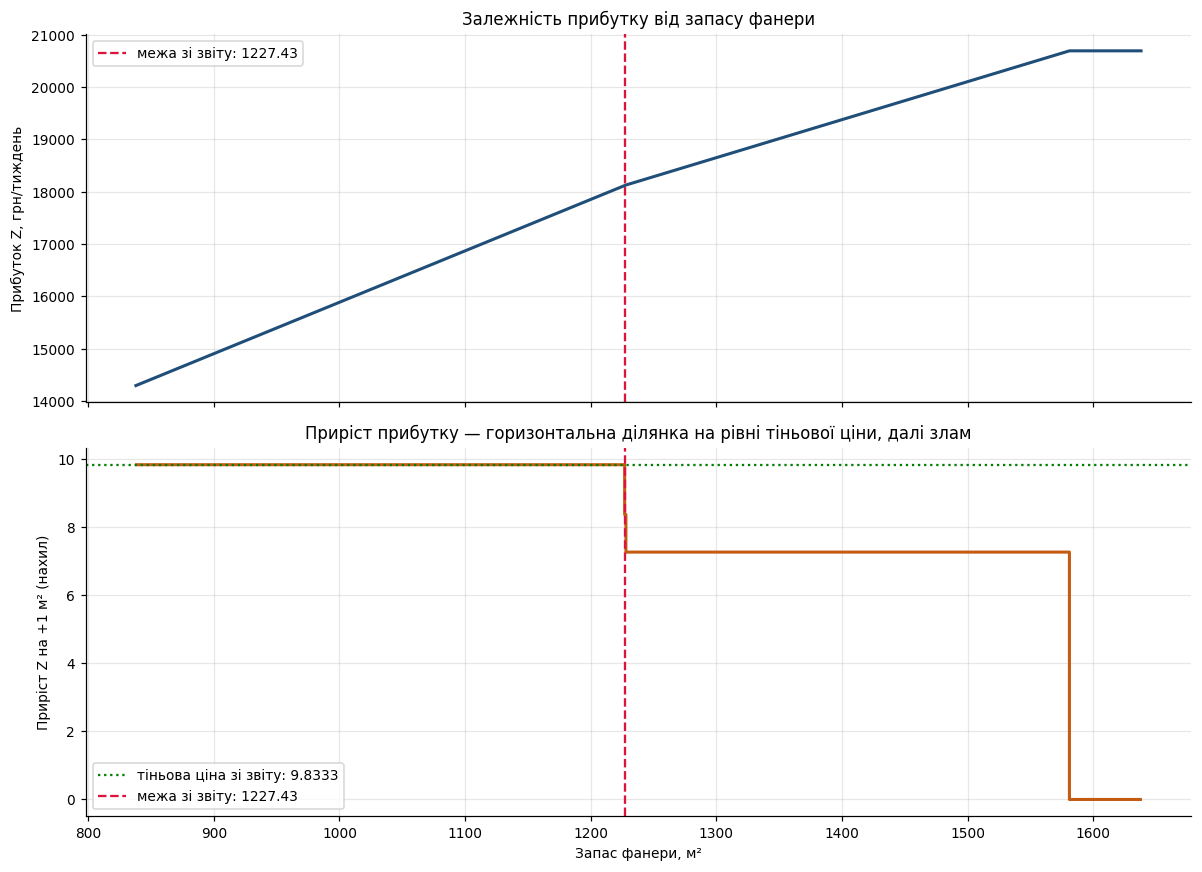

In [91]:
import numpy as np
from scipy.optimize import linprog
import matplotlib.pyplot as plt

c = np.array([30, 16, 51, 35], float)
A = np.array([[2,1,0,3],[3,1,4,0],[1,0,3,2],[3,2,2,6],[3,6,0,3]], float)
b = np.array([1312, 838, 1062, 1038, 1236], float)

i = 1                    # фанера — найдорожчий ресурс за тіньовою ціною
БАЗА = b[i]              # 838
ТІНЬОВА = 9.8333333      # зі звіту
МЕЖА_ЗВІТ = 389.4286     # «допустиме збільшення» зі звіту

def Z(запас):
    bb = b.copy(); bb[i] = запас
    r = linprog(-c, A_ub=A, b_ub=bb, bounds=[(0, None)]*4, method="highs")
    assert r.success
    return -r.fun

# прогін із кроком 1
запаси   = np.arange(БАЗА, БАЗА + 801, 1.0)
прибутки = np.array([Z(v) for v in запаси])

нахил    = np.diff(прибутки)          # приріст Z на кожну додаткову одиницю
середини = запаси[:-1] + 0.5          # нахил належить середині відрізка

# ---- пошук ділянок сталого нахилу ----
print("Ділянки сталого нахилу:")
поч = 0
for k in range(1, len(нахил) + 1):
    if k == len(нахил) or abs(нахил[k] - нахил[поч]) > 1e-7:
        print(f"  запас {запаси[поч]:7.0f} .. {запаси[k]:7.0f}   нахил = {нахил[поч]:.6f}")
        поч = k

злам = запаси[np.argmax(np.abs(нахил - нахил[0]) > 1e-7)]
print(f"\nЗлам між {злам:.0f} і {злам+1:.0f}  →  межа ≈ {злам - БАЗА:.0f}..{злам + 1 - БАЗА:.0f}")
print(f"Допустиме збільшення зі звіту: {МЕЖА_ЗВІТ}  (запас {БАЗА + МЕЖА_ЗВІТ:.4f})")

# ---- два графіки один під одним ----
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

ax1.plot(запаси, прибутки, lw=2, color="#1f4e79")
ax1.axvline(БАЗА + МЕЖА_ЗВІТ, color="crimson", ls="--", lw=1.5,
            label=f"межа зі звіту: {БАЗА + МЕЖА_ЗВІТ:.2f}")
ax1.set_ylabel("Прибуток Z, грн/тиждень")
ax1.set_title("Залежність прибутку від запасу фанери")
ax1.grid(alpha=.3); ax1.legend()

ax2.plot(середини, нахил, lw=2, color="#c55a11", drawstyle="steps-mid")
ax2.axhline(ТІНЬОВА, color="green", ls=":", lw=1.5,
            label=f"тіньова ціна зі звіту: {ТІНЬОВА:.4f}")
ax2.axvline(БАЗА + МЕЖА_ЗВІТ, color="crimson", ls="--", lw=1.5,
            label=f"межа зі звіту: {БАЗА + МЕЖА_ЗВІТ:.2f}")
ax2.set_xlabel("Запас фанери, м²")
ax2.set_ylabel("Приріст Z на +1 м² (нахил)")
ax2.set_title("Приріст прибутку — горизонтальна ділянка на рівні тіньової ціни, далі злам")
ax2.grid(alpha=.3); ax2.legend()

plt.tight_layout()
plt.show()


**Відповідь 5.2:** запас фанери можна збільшити на 389.43 м² (з 838 до 1227.43), доки тіньова ціна лишається 9.8333. Це точно збігається з «допустимим збільшенням»

---
# Етап 6. Рішення про закупівлю

Постачальник пропонує вам додатковий обсяг ресурсу — див. блок «ПРОПОЗИЦІЯ
ПОСТАЧАЛЬНИКА» у ваших даних.

### Завдання 6.1
Дайте відповідь директорові на три питання, спираючись на числа, а не на здоровий глузд:

1. **Брати чи не брати?** Порівняйте ціну пропозиції з тіньовою ціною.
2. **Скільки саме брати?** Постачальник пропонує більше, ніж вам потрібно.
3. **Скільки на цьому заробимо?** Порахуйте виграш і перевірте його прямим
   розв'язанням задачі з новим запасом.

In [92]:
import numpy as np
from scipy.optimize import linprog

c = np.array([30, 16, 51, 35], float)
A = np.array([[2,1,0,3],[3,1,4,0],[1,0,3,2],[3,2,2,6],[3,6,0,3]], float)
b = np.array([1312, 838, 1062, 1038, 1236], float)

i = 1                      # фанера
ЦІНА, ОБСЯГ = 15.6, 778    # пропозиція постачальника

def Z(bb):
    r = linprog(-c, A_ub=A, b_ub=bb, bounds=[(0, None)]*4, method="highs")
    return -r.fun, r.x

Z0, x0 = Z(b)
r0 = linprog(-c, A_ub=A, b_ub=b, bounds=[(0, None)]*4, method="highs")
тіньова = -r0.ineqlin.marginals[i]

# --- 1. Брати чи не брати ---
print(f"Тіньова ціна фанери : {тіньова:.4f} грн/м²")
print(f"Ціна постачальника  : {ЦІНА:.4f} грн/м²")
print(f"Маржа першої одиниці: {тіньова - ЦІНА:+.4f} грн  → "
      f"{'ВИГІДНО' if тіньова > ЦІНА else 'НЕВИГІДНО'}\n")

# --- 2. Скільки брати: закупівля як змінна рішення ---
# нова змінна y: 3x1 + x2 + 4x3 - y <= 838,  y <= 778,  ціль -15.6*y
c2 = np.concatenate([c, [-ЦІНА]])
A2 = np.hstack([A, np.zeros((5, 1))]);  A2[i, 4] = -1
A2 = np.vstack([A2, [0, 0, 0, 0, 1]])
b2 = np.concatenate([b, [ОБСЯГ]])
r2 = linprog(-c2, A_ub=A2, b_ub=b2, bounds=[(0, None)]*5, method="highs")

print("Модель із закупівлею як змінною:")
print(f"  оптимальний обсяг закупівлі y* = {r2.x[4]:.4f} м²")
print(f"  план  = {np.round(r2.x[:4], 4)}")
print(f"  Z     = {-r2.fun:.4f}\n")

# --- 3. Скільки заробимо: перевірка прямим розв'язанням ---
print("Сценарії «купити рівно k м²»:")
for k in [0, 1, 100, 389.4286, 778]:
    bb = b.copy(); bb[i] += k
    Zk, _ = Z(bb)
    валовий, витрати = Zk - Z0, ЦІНА * k
    print(f"  k={k:9.4f}: валовий {валовий:10.4f} − витрати {витрати:10.4f}"
          f" = ЧИСТО {валовий - витрати:11.4f}")

print(f"\nМаксимальна прийнятна ціна = тіньова ціна = {тіньова:.4f} грн/м²")


Тіньова ціна фанери : 9.8333 грн/м²
Ціна постачальника  : 15.6000 грн/м²
Маржа першої одиниці: -5.7667 грн  → НЕВИГІДНО

Модель із закупівлею як змінною:
  оптимальний обсяг закупівлі y* = 0.0000 м²
  план  = [  0.       0.     209.5    103.1667]
  Z     = 14295.3333

Сценарії «купити рівно k м²»:
  k=   0.0000: валовий     0.0000 − витрати     0.0000 = ЧИСТО      0.0000
  k=   1.0000: валовий     9.8333 − витрати    15.6000 = ЧИСТО     -5.7667
  k= 100.0000: валовий   983.3333 − витрати  1560.0000 = ЧИСТО   -576.6667
  k= 389.4286: валовий  3829.3812 − витрати  6075.0862 = ЧИСТО  -2245.7050
  k= 778.0000: валовий  6398.6667 − витрати 12136.8000 = ЧИСТО  -5738.1333

Максимальна прийнятна ціна = тіньова ціна = 9.8333 грн/м²


**Відповідь 6.1:**

* Брати чи ні і чому:
Не брати. Тіньова ціна фанери — 9.8333 грн/м², постачальник просить 15.6 грн/м². Кожен куплений метр додає 9.83 грн прибутку і забирає 15.60 грн витрат, тобто дає збиток 5.77 грн. Це стосується вже першої одиниці, а не тільки великих обсягів.
* Скільки одиниць має сенс купити і чому не більше:
Нуль. Це не округлення й не обережність — модель із закупівлею як повноцінною змінною рішення дала y* = 0.0000. Питання «скільки саме брати» тут має вироджену відповідь: невигідна вже перша одиниця, тому оптимум лежить на межі. Ліміт постачальника в 778 м² і межа стійкості в 389.43 м² у цій задачі не спрацьовують — вони обмежували б покупку, якби вона взагалі була вигідною.
* Очікуваний виграш:
0 грн. Прибуток лишається 14 295.33 грн/тиждень. Якби директор наполіг і взяв усю партію 778 м², підприємство втратило б 5 738.13 грн за тиждень.
* Перевірка прямим розв'язанням дала:
Збіг. Розширена модель із змінною y самостійно обрала y* = 0 і повернула той самий план (0, 0, 209.5, 103.1667) та той самий прибуток 14 295.3333 — тобто вона незалежно підтвердила висновок, зроблений із тіньової ціни.


---
# Етап 7. Перевірка розв'язку

### Завдання 7.1
Порахуйте дві величини:

* скільки виробів мають **ненульовий** випуск;
* скільки обмежень **зв'язні** (ресурс витрачено повністю).

Порівняйте.

In [93]:
import numpy as np
from scipy.optimize import linprog

c = np.array([30, 16, 51, 35], float)
A = np.array([[2,1,0,3],[3,1,4,0],[1,0,3,2],[3,2,2,6],[3,6,0,3]], float)
b = np.array([1312, 838, 1062, 1038, 1236], float)

ВИРОБИ  = ["Крісло", "Стілець", "Табурет", "Лава"]
РЕСУРСИ = ["Дубовий брус", "Фанера", "Фурнітура", "Верстат", "Лакування"]
EPS = 1e-9          # поріг: симплекс дає 1e-14 замість чистого нуля

r = linprog(-c, A_ub=A, b_ub=b, bounds=[(0, None)]*4, method="highs")
x = r.x
залишки = b - A @ x

ненульових = int(np.sum(x > EPS))          # скільки виробів випускається
звязних    = int(np.sum(залишки < EPS))    # скільки ресурсів вичерпано

print("Випуск:")
for назва, v in zip(ВИРОБИ, x):
    print(f"  {назва:9s} {v:10.4f}  {'НЕНУЛЬОВИЙ' if v > EPS else '—'}")

print("\nЗалишки ресурсів:")
for назва, s in zip(РЕСУРСИ, залишки):
    print(f"  {назва:14s} {s:10.4f}  {'ЗВ’ЯЗНЕ' if s < EPS else '—'}")

print(f"\nненульових = {ненульових}")
print(f"зв’язних   = {звязних}")
print(f"збіг: {ненульових == звязних}")

Випуск:
  Крісло        0.0000  —
  Стілець       0.0000  —
  Табурет     209.5000  НЕНУЛЬОВИЙ
  Лава        103.1667  НЕНУЛЬОВИЙ

Залишки ресурсів:
  Дубовий брус    1002.5000  —
  Фанера             0.0000  ЗВ’ЯЗНЕ
  Фурнітура        227.1667  —
  Верстат            0.0000  ЗВ’ЯЗНЕ
  Лакування        926.5000  —

ненульових = 2
зв’язних   = 2
збіг: True


In [94]:
assert ненульових is not None and звязних is not None, 'спершу порахуйте'
print('ненульових змінних: %s | зв’язних обмежень: %s' % (ненульових, звязних))
assert ненульових == звязних, ('числа не збіглися — це сигнал. Перевірте розв’язок '
                               'і поясніть причину в клітинці нижче')
print('Етап 7 пройдено')

ненульових змінних: 2 | зв’язних обмежень: 2
Етап 7 пройдено


**Відповідь 7.1:** числа збіглися — два ненульових вироби (табурет, лава) і два зв'язні обмеження (фанера, верстат). Це ознака невиродженого базисного розв'язку: розв'язок «здоровий», його можна інтерпретувати без застережень, і тіньові ціни зі звіту однозначні.

---
# Етап 8. Цілочисельність

Ваш оптимальний план містить дробові числа. Виготовити 63,3 виробу неможливо.

### Завдання 8.1
Порівняйте три варіанти:

1. розв'язок без умови цілочисельності (уже маєте);
2. **округлений** план — округліть кожне значення до цілого й перевірте, чи він
   узагалі допустимий і скільки прибутку дає;
3. справжній **цілочисельний** оптимум — розв'яжіть задачу з умовою, що всі змінні цілі
   (`cat='Integer'` у PuLP або `integrality=1` у `linprog`).

In [95]:
import numpy as np
from scipy.optimize import linprog

c = np.array([30, 16, 51, 35], float)
A = np.array([[2,1,0,3],[3,1,4,0],[1,0,3,2],[3,2,2,6],[3,6,0,3]], float)
b = np.array([1312, 838, 1062, 1038, 1236], float)
РЕСУРСИ = ["Дубовий брус", "Фанера", "Фурнітура", "Верстат", "Лакування"]

def допустимий(x):
    витрата = A @ x
    return np.all(витрата <= b + 1e-9), витрата

def показати(назва, x):
    ok, витрата = допустимий(x)
    print(f"\n{назва}")
    print(f"  план     = {np.round(x, 4)}")
    print(f"  прибуток = {c @ x:.4f}")
    print(f"  допустимий: {ok}")
    for n, u, bb in zip(РЕСУРСИ, витрата, b):
        мітка = "OK" if u <= bb + 1e-9 else "← ПОРУШЕНО"
        print(f"    {n:14s} {u:9.2f} <= {bb:7.0f}  {мітка}")

# 1) без умови цілочисельності
r_lp  = linprog(-c, A_ub=A, b_ub=b, bounds=[(0, None)]*4, method="highs")
x_lp  = r_lp.x
показати("1) БЕЗ ЦІЛОЧИСЕЛЬНОСТІ", x_lp)

# 2) округлений план
x_r = np.round(x_lp)
показати("2) ОКРУГЛЕНИЙ", x_r)

# 2b) округлення вниз — про всяк випадок
показати("2b) ОКРУГЛЕННЯ ВНИЗ (floor)", np.floor(x_lp))

# 3) справжній цілочисельний оптимум
r_int = linprog(-c, A_ub=A, b_ub=b, bounds=[(0, None)]*4,
                method="highs", integrality=np.ones(4))
x_int = np.round(r_int.x)          # прибираємо шум 1e-13
показати("3) ЦІЛОЧИСЕЛЬНИЙ ОПТИМУМ", x_int)

print(f"\nВтрата від цілочисельності: {c @ x_lp - c @ x_int:.4f} грн/тиждень")



1) БЕЗ ЦІЛОЧИСЕЛЬНОСТІ
  план     = [  0.       0.     209.5    103.1667]
  прибуток = 14295.3333
  допустимий: True
    Дубовий брус      309.50 <=    1312  OK
    Фанера            838.00 <=     838  OK
    Фурнітура         834.83 <=    1062  OK
    Верстат          1038.00 <=    1038  OK
    Лакування         309.50 <=    1236  OK

2) ОКРУГЛЕНИЙ
  план     = [  0.   0. 210. 103.]
  прибуток = 14315.0000
  допустимий: False
    Дубовий брус      309.00 <=    1312  OK
    Фанера            840.00 <=     838  ← ПОРУШЕНО
    Фурнітура         836.00 <=    1062  OK
    Верстат          1038.00 <=    1038  OK
    Лакування         309.00 <=    1236  OK

2b) ОКРУГЛЕННЯ ВНИЗ (floor)
  план     = [  0.   0. 209. 103.]
  прибуток = 14264.0000
  допустимий: True
    Дубовий брус      309.00 <=    1312  OK
    Фанера            836.00 <=     838  OK
    Фурнітура         833.00 <=    1062  OK
    Верстат          1036.00 <=    1038  OK
    Лакування         309.00 <=    1236  OK

3) ЦІЛОЧИСЕЛ

**Відповідь 8.1:**

| Варіант | План | Прибуток | Допустимий?                    |
|---|---|---|--------------------------------|
| без умови цілочисельності | (0; 0; 209.5; 103.1667) | 14295.33 | так                            |
| округлений | (0; 0; 210; 103) | 14315.00 | ні - фанери 840 при запасі 838 |
| округлення вниз | (0; 0; 209; 103) | 14264.00 | так, але не оптимальний        |
| цілочисельний оптимум | (0; 1; 209; 103) | 14280.00 | так                            |
**Висновок:** округлювати не можна - округлення вгору дає недопустимий план
(фанери треба 840 при запасі 838), а вниз недобирає 16 грн. Цілочисельний
оптимум має іншу структуру (з'явився стілець, який LP відкинув) і шукається
окремо, методом гілок і меж.


---
# ЧАСТИНА 2. Транспортна задача

Друга частина виконується самостійно. Тут ви застосуєте ту саму методику до задачі
іншого класу — і побачите, що вона поводиться інакше.

# Етап 9. Ваші дані

### Завдання 9.1
Сформуйте власні дані:

* **три міста-постачальники** — за першими трьома літерами вашого **прізвища**;
* **чотири міста-споживачі** — за першими чотирма літерами вашого **імені**;
* **матриця відстаней 3 × 4** — реальні відстані автошляхами за Google Maps, у кілометрах;
* **запаси і попит** — невеликі цілі числа, підберіть так, щоб **сумарний запас
  дорівнював сумарному попиту**.

> Якщо на якусь літеру міста немає — беріть наступну літеру прізвища чи імені.
> Якщо сумарний запас не дорівнює попиту, задача з обмеженнями-рівностями
> **не матиме розв'язку взагалі**. Це не помилка Python — це властивість моделі.

In [96]:
# ВАШ КОД — впишіть свої дані
import numpy as np
import pandas as pd

# Кривичко → К, Р, (И — міст немає) → В
постачальники = ['Київ', 'Рівне', 'Вінниця']

# Назар → Н, А, З, А
споживачі = ['Ніжин', 'Ананьїв', 'Звенигородка', 'Андрушівка']

# Відстані автошляхами, км (рядок = постачальник, стовпець = споживач)
D = np.array([
    [145, 390, 190, 180],   # Київ
    [450, 590, 410, 230],   # Рівне
    [420, 290, 220, 120],   # Вінниця
], float)

запас = [40, 30, 30]          # разом 100
попит = [25, 20, 30, 25]      # разом 100

assert len(постачальники) == 3 and len(споживачі) == 4, 'потрібно 3 постачальники і 4 споживачі'
assert D.shape == (3, 4), 'матриця відстаней має бути 3 x 4'
assert sum(запас) == sum(попит), 'сумарний запас має дорівнювати сумарному попиту'
pd.DataFrame(D, index=постачальники, columns=споживачі)

,Ніжин,Ананьїв,Звенигородка,Андрушівка
Київ,145.0,390.0,190.0,180.0
Рівне,450.0,590.0,410.0,230.0
Вінниця,420.0,290.0,220.0,120.0


---
# Етап 10. Розв'язання транспортної задачі

### Завдання 10.1
Розв'яжіть задачу **двічі різними засобами**: наприклад `pulp` і
`scipy.optimize.linprog(method='highs')`. Обмеження — рівності.

Для кожного розв'язку виведіть: оптимальний план перевезень, сумарну вартість
і **тіньові ціни всіх обмежень**.

In [97]:
# ВАШ КОД — розв'язок 1
import numpy as np, pandas as pd
from scipy.optimize import linprog

пост = ['Київ', 'Рівне', 'Вінниця']
спож = ['Ніжин', 'Ананьїв', 'Звенигородка', 'Андрушівка']
D = np.array([[145, 390, 190, 180],
              [450, 590, 410, 230],
              [420, 290, 220, 120]], float)
запас, попит = [40, 30, 30], [25, 20, 30, 25]
m, n = D.shape

# змінні розгортаємо в один вектор довжиною 12: x[i*n + j]
c = D.flatten()

A_eq, b_eq = [], []
for i in range(m):                      # рядки: вивезти весь запас
    r = np.zeros(m*n); r[i*n:(i+1)*n] = 1
    A_eq.append(r); b_eq.append(запас[i])
for j in range(n):                      # стовпці: задовольнити весь попит
    r = np.zeros(m*n); r[j::n] = 1
    A_eq.append(r); b_eq.append(попит[j])

r = linprog(c, A_eq=np.array(A_eq), b_eq=np.array(b_eq),
            bounds=[(0, None)]*(m*n), method='highs')
assert r.success, r.message

X = r.x.reshape(m, n)
print("СПОСІБ 1 — scipy.optimize.linprog\n")
print("План перевезень, од.:")
print(pd.DataFrame(np.round(X, 4), index=пост, columns=спож), "\n")
print(f"Сумарна вартість = {r.fun:,.2f} км·од.\n")

u, v = r.eqlin.marginals[:m], r.eqlin.marginals[m:]
print("Тіньові ціни (потенціали):")
for назва, знач in zip(пост, u):
    print(f"  запас  {назва:14s} u = {знач:9.4f}")
for назва, знач in zip(спож, v):
    print(f"  попит  {назва:14s} v = {знач:9.4f}")

print("\nПеревірка u_i + v_j = c_ij для задіяних маршрутів:")
for i in range(m):
    for j in range(n):
        if X[i, j] > 1e-9:
            print(f"  {пост[i]:8s}->{спож[j]:14s} {u[i]+v[j]:8.2f} = {D[i,j]:6.0f}")

СПОСІБ 1 — scipy.optimize.linprog

План перевезень, од.:
         Ніжин  Ананьїв  Звенигородка  Андрушівка
Київ      25.0      0.0          15.0         0.0
Рівне      0.0      0.0           5.0        25.0
Вінниця    0.0     20.0          10.0         0.0 

Сумарна вартість = 22,275.00 км·од.

Тіньові ціни (потенціали):
  запас  Київ           u =  260.0000
  запас  Рівне          u =  480.0000
  запас  Вінниця        u =  290.0000
  попит  Ніжин          v = -115.0000
  попит  Ананьїв        v =   -0.0000
  попит  Звенигородка   v =  -70.0000
  попит  Андрушівка     v = -250.0000

Перевірка u_i + v_j = c_ij для задіяних маршрутів:
  Київ    ->Ніжин            145.00 =    145
  Київ    ->Звенигородка     190.00 =    190
  Рівне   ->Звенигородка     410.00 =    410
  Рівне   ->Андрушівка       230.00 =    230
  Вінниця ->Ананьїв          290.00 =    290
  Вінниця ->Звенигородка     220.00 =    220


In [98]:
# ВАШ КОД — розв'язок 2
import numpy as np, pandas as pd, pulp

пост = ['Київ', 'Рівне', 'Вінниця']
спож = ['Ніжин', 'Ананьїв', 'Звенигородка', 'Андрушівка']
D = np.array([[145, 390, 190, 180],
              [450, 590, 410, 230],
              [420, 290, 220, 120]], float)
запас, попит = [40, 30, 30], [25, 20, 30, 25]
m, n = D.shape

prob = pulp.LpProblem("transport", pulp.LpMinimize)
x = {(i, j): pulp.LpVariable(f"x_{i}_{j}", lowBound=0)
     for i in range(m) for j in range(n)}

prob += pulp.lpSum(D[i][j] * x[i, j] for i in range(m) for j in range(n))

for i in range(m):
    prob += pulp.lpSum(x[i, j] for j in range(n)) == запас[i], f"запас_{пост[i]}"
for j in range(n):
    prob += pulp.lpSum(x[i, j] for i in range(m)) == попит[j], f"попит_{спож[j]}"

prob.solve(pulp.PULP_CBC_CMD(msg=0))
assert pulp.LpStatus[prob.status] == "Optimal"

X = np.array([[x[i, j].value() for j in range(n)] for i in range(m)])
print("СПОСІБ 2 — PuLP / CBC\n")
print("План перевезень, од.:")
print(pd.DataFrame(X, index=пост, columns=спож), "\n")
print(f"Сумарна вартість = {pulp.value(prob.objective):,.2f} км·од.\n")

print("Тіньові ціни (атрибут .pi кожного обмеження):")
for назва, con in prob.constraints.items():
    print(f"  {назва:26s} {con.pi:10.4f}")

СПОСІБ 2 — PuLP / CBC

План перевезень, од.:
         Ніжин  Ананьїв  Звенигородка  Андрушівка
Київ      25.0      0.0          15.0         0.0
Рівне      0.0      0.0           5.0        25.0
Вінниця    0.0     20.0          10.0         0.0 

Сумарна вартість = 22,275.00 км·од.

Тіньові ціни (атрибут .pi кожного обмеження):
  запас_Київ                   145.0000
  запас_Рівне                  365.0000
  запас_Вінниця                175.0000
  попит_Ніжин                    0.0000
  попит_Ананьїв                115.0000
  попит_Звенигородка            45.0000
  попит_Андрушівка            -135.0000


### Завдання 10.2 — головне питання цієї частини
Порівняйте два набори тіньових цін.

**Сумарна вартість у двох розв'язувачів однакова. А тіньові ціни?**

Якщо вони різні — це не помилка. Знайдіть закономірність: подивіться на різницю
між відповідними значеннями окремо для постачальників і окремо для споживачів.

In [99]:
# ВАШ КОД — порівняння
import numpy as np, pandas as pd, pulp
from scipy.optimize import linprog

m, n = D.shape

# ---- дуальні змінні від scipy ----
A_eq, b_eq = [], []
for i in range(m):
    r = np.zeros(m*n); r[i*n:(i+1)*n] = 1
    A_eq.append(r); b_eq.append(запас[i])
for j in range(n):
    r = np.zeros(m*n); r[j::n] = 1
    A_eq.append(r); b_eq.append(попит[j])

rs = linprog(D.flatten(), A_eq=np.array(A_eq), b_eq=np.array(b_eq),
             bounds=[(0, None)]*(m*n), method='highs')
u_sp, v_sp = rs.eqlin.marginals[:m], rs.eqlin.marginals[m:]
X_sp, Z_sp = rs.x.reshape(m, n), rs.fun

# ---- дуальні змінні від PuLP ----
prob = pulp.LpProblem("t", pulp.LpMinimize)
x = {(i, j): pulp.LpVariable(f"x_{i}_{j}", lowBound=0)
     for i in range(m) for j in range(n)}
prob += pulp.lpSum(D[i][j]*x[i, j] for i in range(m) for j in range(n))
for i in range(m):
    prob += pulp.lpSum(x[i, j] for j in range(n)) == запас[i], f"s{i}"
for j in range(n):
    prob += pulp.lpSum(x[i, j] for i in range(m)) == попит[j], f"d{j}"
prob.solve(pulp.PULP_CBC_CMD(msg=0))

u_pl = np.array([prob.constraints[f"s{i}"].pi for i in range(m)])
v_pl = np.array([prob.constraints[f"d{j}"].pi for j in range(n)])
X_pl = np.array([[x[i, j].value() for j in range(n)] for i in range(m)])
Z_pl = pulp.value(prob.objective)

# ---- порівняння ----
print(f"Вартість: scipy {Z_sp:,.2f} | pulp {Z_pl:,.2f} | збіг: {abs(Z_sp-Z_pl) < 1e-6}")
print(f"Плани ідентичні: {np.allclose(X_sp, X_pl)}\n")

print(pd.DataFrame({'scipy': u_sp, 'pulp': u_pl, 'різниця': u_sp-u_pl}, index=пост), "\n")
print(pd.DataFrame({'scipy': v_sp, 'pulp': v_pl, 'різниця': v_sp-v_pl}, index=спож))

t = (u_sp - u_pl)[0]
print(f"\nЗсув t = {t:.4f}")
print(f"  усі u зсунуті на {t:+.4f}:  {np.allclose(u_sp-u_pl,  t)}")
print(f"  усі v зсунуті на {-t:+.4f}: {np.allclose(v_sp-v_pl, -t)}")

S_sp = u_sp[:, None] + v_sp[None, :]
S_pl = u_pl[:, None] + v_pl[None, :]
print(f"\nСуми u_i+v_j збігаються в усіх {m*n} клітинках: {np.allclose(S_sp, S_pl)}")
print("\nМатриця u_i + v_j (однакова в обох):")
print(pd.DataFrame(S_sp, index=пост, columns=спож))
print("\nОцінки маршрутів c_ij − (u_i+v_j) — теж однакові:")
print(pd.DataFrame(D - S_sp, index=пост, columns=спож))

Вартість: scipy 22,275.00 | pulp 22,275.00 | збіг: True
Плани ідентичні: True

         scipy   pulp  різниця
Київ     260.0  145.0    115.0
Рівне    480.0  365.0    115.0
Вінниця  290.0  175.0    115.0 

              scipy   pulp  різниця
Ніжин        -115.0    0.0   -115.0
Ананьїв        -0.0  115.0   -115.0
Звенигородка  -70.0   45.0   -115.0
Андрушівка   -250.0 -135.0   -115.0

Зсув t = 115.0000
  усі u зсунуті на +115.0000:  True
  усі v зсунуті на -115.0000: True

Суми u_i+v_j збігаються в усіх 12 клітинках: True

Матриця u_i + v_j (однакова в обох):
         Ніжин  Ананьїв  Звенигородка  Андрушівка
Київ     145.0    260.0         190.0        10.0
Рівне    365.0    480.0         410.0       230.0
Вінниця  175.0    290.0         220.0        40.0

Оцінки маршрутів c_ij − (u_i+v_j) — теж однакові:
         Ніжин  Ананьїв  Звенигородка  Андрушівка
Київ       0.0    130.0           0.0       170.0
Рівне     85.0    110.0           0.0         0.0
Вінниця  245.0      0.0           0

**Відповідь 10.2:**

* Вартість у двох розв'язувачів:
* Вартість у двох розв'язувачів: однакова - 22275.00 км·од. в обох. Плани
  перевезень теж ідентичні до останньої одиниці.

* Тіньові ціни збіглися чи ні:
Тіньові ціни збіглися чи ні: НЕ збіглися. scipy дав u = (260, 480, 290) і
  v = (-115, 0, -70, -250); PuLP дав u = (145, 365, 175) і v = (0, 115, 45, -135).
* Яку закономірність ви побачили в різниці:
 Яку закономірність я побачив у різниці: різниця стала і протилежна за знаком
  для двох груп. Усі тіньові ціни постачальників у scipy рівно на +115 більші,
  а всі тіньові ціни споживачів — рівно на -115 менші, ніж у PuLP:

      різниця u = [+115, +115, +115]
      різниця v = [-115, -115, -115, -115]

  Через це суми u_i + v_j у двох розв'язувачів збігаються ТОЧНО, у всіх 12
  клітинках (перевірено: матриця різниць складається з нулів). Різниці всередині
  однієї групи теж збігаються: u_Рівне - u_Київ = 220 в обох, v_Ананьїв -
  v_Ніжин = 115 в обох.

  Причина: у збалансованій транспортній задачі (сума запасів = сума попиту) одне
  з семи обмежень надлишкове — воно автоматично випливає з решти шести. Тому
  система u_i + v_j = c_ij недовизначена на одну ступінь свободи: до всіх u можна
  додати будь-яку константу t, а від усіх v відняти ту саму t, і всі рівності
  лишаться правдивими. Розв'язувачі закріплюють цю свободу по-різному: CBC
  занулив v першого споживача, HiGHS обрав інший зсув. Обидва відповіді коректні.
  
* Що це означає для того, хто збирається ухвалювати рішення за цим звітом:
абсолютні значення тіньових цін у транспортній задачі НЕ МАЮТЬ САМОСТІЙНОГО СЕНСУ і на них не
можна спиратися. Питання «скільки коштує одиниця запасу в Києві» тут не має
однозначної відповіді - 260 чи 145 залежить від того, який розв'язувач
запустили.
Практичний висновок: перед тим як порівнювати тіньові ціни двох звітів,
нормуйте їх — прирівняйте один із потенціалів до нуля. Інакше можна зробити
протилежні висновки з математично тотожних розв'язків.


---
# Етап 11. Перевірка розв'язку — і чому вона тут не працює

### Завдання 11.1
Порахуйте для транспортної задачі те саме, що на етапі 7:

* кількість **ненульових перевезень**;
* кількість **зв'язних обмежень**.

Порівняйте з числом `3 + 4 = 7` — кількістю обмежень у задачі.

In [100]:
# ВАШ КОД
import numpy as np, pandas as pd

m, n = D.shape
EPS = 1e-9
X = X_sp                      # план із 10.2 (або X із 10.1 — вони однакові)

ненульових_тр = int(np.sum(X > EPS))

нев_рядків = np.abs(X.sum(axis=1) - np.array(запас))    # недовиконання по запасах
нев_стовп  = np.abs(X.sum(axis=0) - np.array(попит))    # недовиконання по попиту
звязних_тр    = int(np.sum(нев_рядків < EPS) + np.sum(нев_стовп < EPS))

print("План перевезень:")
print(pd.DataFrame(X, index=пост, columns=спож))

print("\nРядки — вивезено vs запас:")
for k, назва in enumerate(пост):
    print(f"  {назва:14s} {X[k].sum():7.2f} = {запас[k]:5d}  "
          f"{'ЗВ’ЯЗНЕ' if нев_рядків[k] < EPS else '—'}")

print("Стовпці — довезено vs попит:")
for k, назва in enumerate(спож):
    print(f"  {назва:14s} {X[:, k].sum():7.2f} = {попит[k]:5d}  "
          f"{'ЗВ’ЯЗНЕ' if нев_стовп[k] < EPS else '—'}")

print(f"\nненульових перевезень = {ненульових_тр}")
print(f"зв’язних обмежень     = {звязних_тр}  з  {m + n}")
print(f"m + n − 1             = {m + n - 1}")
print(f"клітинок усього       = {m * n}")
print(f"\nчи збіглися, як на етапі 7: {ненульових_тр == звязних_тр}")

План перевезень:
         Ніжин  Ананьїв  Звенигородка  Андрушівка
Київ      25.0      0.0          15.0         0.0
Рівне      0.0      0.0           5.0        25.0
Вінниця    0.0     20.0          10.0         0.0

Рядки — вивезено vs запас:
  Київ             40.00 =    40  ЗВ’ЯЗНЕ
  Рівне            30.00 =    30  ЗВ’ЯЗНЕ
  Вінниця          30.00 =    30  ЗВ’ЯЗНЕ
Стовпці — довезено vs попит:
  Ніжин            25.00 =    25  ЗВ’ЯЗНЕ
  Ананьїв          20.00 =    20  ЗВ’ЯЗНЕ
  Звенигородка     30.00 =    30  ЗВ’ЯЗНЕ
  Андрушівка       25.00 =    25  ЗВ’ЯЗНЕ

ненульових перевезень = 6
зв’язних обмежень     = 7  з  7
m + n − 1             = 6
клітинок усього       = 12

чи збіглися, як на етапі 7: False


**Відповідь 11.1:**

* Ненульових перевезень: 6
  (Київ→Ніжин 25, Київ→Звенигородка 15, Рівне→Звенигородка 5,
   Рівне→Андрушівка 25, Вінниця→Ананьїв 20, Вінниця→Звенигородка 10)

* Зв'язних обмежень: 7 - тобто ВСІ. Перевірка етапу 7 тут не спрацьовує:
  числа 6 і 7 не збігаються.

* Чому в транспортній задачі зв'язними виявляються ВСІ обмеження:
  бо обмеження задані РІВНОСТЯМИ, а не нерівностями. У виробничій задачі
  стояло «витратити не більше, ніж є» (≤), і ресурс міг лишитися невикористаним
  - звідси надлишкові, незв'язні обмеження. Тут стоїть «вивезти рівно весь запас»
  і «довезти рівно весь попит» (=). Рівність не має слабини за побудовою: якщо
  розв'язок допустимий, кожна рівність виконана точно. Тому питання «які
  обмеження зв'язні» у транспортній задачі позбавлене сенсу — відповідь завжди
  «всі», незалежно від даних.
* На скільки ненульових перевезень менше і чому саме на стільки:
Ненульових 6 = m + n − 1 = 3 + 4 − 1, а обмежень 7 = m + n.
 Причина — надлишковість однієї рівності. Сума всіх рядкових обмежень дає
  «вивезено всього = 100», сума всіх стовпцевих — «довезено всього = 100».
  Це одне й те саме рівняння. Тому будь-яке одне з семи обмежень автоматично
  випливає з решти шести, і незалежних серед них лише 6. Базисний розв'язок
  містить стільки ненульових змінних, скільки є НЕЗАЛЕЖНИХ обмежень, а не
  скільки їх записано.


### Завдання 11.2 — візуалізація
Побудуйте дві теплові карти поруч: матрицю відстаней і матрицю оптимальних перевезень.
Підпишіть осі та значення в комірках.

*За бажанням (не оцінюється): граф маршрутів через `networkx`, де товщина ребра
пропорційна обсягу перевезення.*

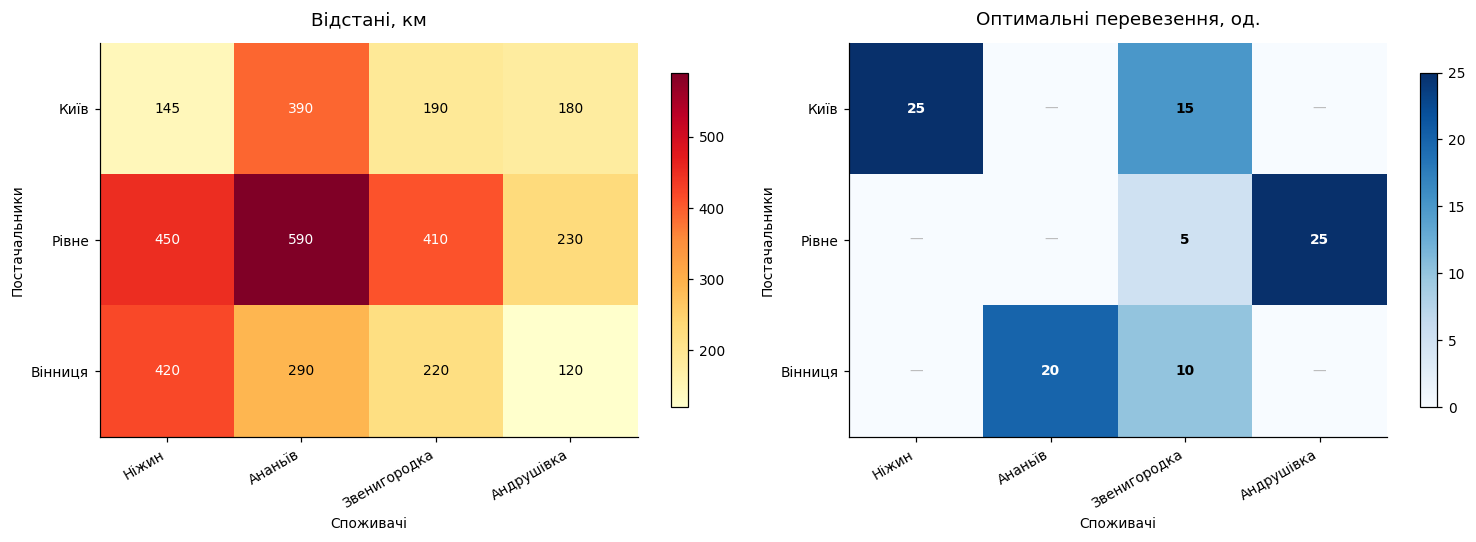

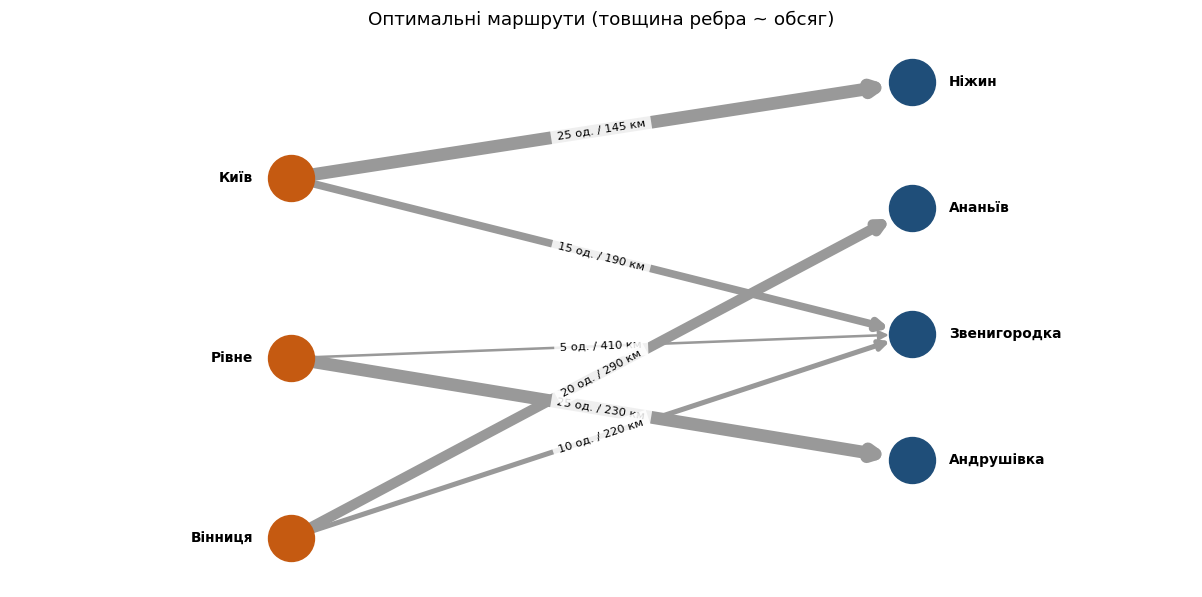

In [101]:
import numpy as np
import matplotlib.pyplot as plt

X = X_sp                       # план із попередніх етапів
m, n = D.shape

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, M, назва, cmap in [(axes[0], D, "Відстані, км", "YlOrRd"),
                           (axes[1], X, "Оптимальні перевезення, од.", "Blues")]:
    im = ax.imshow(M, cmap=cmap, aspect="auto")
    ax.set_xticks(range(n)); ax.set_xticklabels(спож, rotation=30, ha="right")
    ax.set_yticks(range(m)); ax.set_yticklabels(пост)
    ax.set_title(назва, fontsize=12, pad=12)
    ax.set_xlabel("Споживачі"); ax.set_ylabel("Постачальники")

    поріг = M.max() * 0.6                      # світлий текст на темному тлі
    for i in range(m):
        for j in range(n):
            колір = "white" if M[i, j] > поріг else "black"
            текст = f"{M[i, j]:.0f}"
            жирний = "normal"
            if M is X:
                if M[i, j] < 1e-9:
                    текст, колір = "—", "#bbbbbb"   # незадіяний маршрут
                else:
                    жирний = "bold"
            ax.text(j, i, текст, ha="center", va="center",
                    color=колір, fontweight=жирний)
    fig.colorbar(im, ax=ax, shrink=.85)

plt.tight_layout()
plt.show()


import networkx as nx

G = nx.DiGraph(); поз = {}
for i, s in enumerate(пост): поз[s] = (0, -i*1.5);      G.add_node(s)
for j, s in enumerate(спож): поз[s] = (2, -j*1.05+0.8); G.add_node(s)
for i in range(m):
    for j in range(n):
        if X[i, j] > 1e-9:
            G.add_edge(пост[i], спож[j], обсяг=X[i, j], км=D[i, j])

fig, ax = plt.subplots(figsize=(11, 5.5))
nx.draw_networkx_nodes(G, поз, nodelist=пост, node_color="#c55a11", node_size=900, ax=ax)
nx.draw_networkx_nodes(G, поз, nodelist=спож, node_color="#1f4e79", node_size=900, ax=ax)

обс = [G[u][v]['обсяг'] for u, v in G.edges()]
nx.draw_networkx_edges(G, поз, width=[o/3 for o in обс], edge_color="#999999",
                       arrowsize=13, node_size=900, ax=ax)

підп = {(u, v): f"{G[u][v]['обсяг']:.0f} од. / {G[u][v]['км']:.0f} км" for u, v in G.edges()}
nx.draw_networkx_edge_labels(G, поз, edge_labels=підп, font_size=7.5,
                             bbox=dict(fc="white", ec="none", alpha=.85), ax=ax)

# підписи міст поза вузлами, щоб довгі назви не обрізалися
for s in пост: ax.text(поз[s][0]-0.12, поз[s][1], s, ha="right", va="center", fontweight="bold")
for s in спож: ax.text(поз[s][0]+0.12, поз[s][1], s, ha="left",  va="center", fontweight="bold")

ax.set_xlim(-0.9, 2.9)
ax.set_title("Оптимальні маршрути (товщина ребра ~ обсяг)", fontsize=12)
ax.axis("off"); plt.tight_layout(); plt.show()


**Висновок:** 
Ліва карта - вхідні дані. У клітинці стоїть відстань у кілометрах. Що темніший червоний, то довше плече. Найтемніша клітинка - Рівне→Ананьїв (590 км), найсвітліша - Вінниця→Андрушівка (120 км).
Права карта - відповідь. У клітинці стоїть обсяг перевезення в одиницях. Синє - маршрут задіяно, прочерк - не задіяно. Заповнених клітинок рівно 6 із 12.


---
# Етап 12. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями **дозволено**. Обов'язковою є прозорість.
Порушенням є не використання інструмента, а нездатність пояснити власний код
і власні числа на захисті.

Для кожного етапу оберіть одне: `'ні'`, `'синтаксис'`, `'код, перевірено'`,
`'текст, перероблено'`, `'текст, як є'`.

In [102]:
ІНСТРУМЕНТИ_ШІ = 'Claude, ChatGPT'     # напр. 'ChatGPT' або 'не використовував'

ДЕКЛАРАЦІЯ = {
    'етап 1, формалізація моделі':          'код, перевірено',
    'етап 2, побудова моделі в Excel':      'код, перевірено',
    'етап 3, код на Python':                'код, перевірено',
    'етапи 4–5, читання та перевірка звіту': 'код, перевірено',
    'етап 6, рішення про закупівлю':        'код, перевірено',
    'етапи 7–8, перевірка та цілочисельність': 'код, перевірено',
    'етапи 9–11, транспортна задача':       'код, перевірено',
}

# Що саме ви перевірили за згенерованим кодом чи текстом — конкретно.
ЩО_ПЕРЕВІРЕНО = 'Перевірив обрахунок в транспортній задачі а саме подивився чому саме і як це в коді видно що значення відрізняються на 115 од в тіньових цінах в результаті методів. ПС: ШІ пояснив що використані різні методи'

# True означає: я можу пояснити кожен рядок свого коду, відтворити будь-яке число
# цієї роботи та внести зміни в модель на вимогу під час захисту.
ПІДТВЕРДЖУЮ = True

In [103]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}
assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше (зараз %d символів, '
                                           'потрібно щонайменше 120)' % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'
print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-42s %s' % ('автор:', ПІБ))
print('%-42s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-42s %s' % (k + ':', v))
print('-' * 78)
print(ЩО_ПЕРЕВІРЕНО)

ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ
автор:                                     Кривичко Назар
інструменти:                               Claude, ChatGPT
------------------------------------------------------------------------------
етап 1, формалізація моделі:               код, перевірено
етап 2, побудова моделі в Excel:           код, перевірено
етап 3, код на Python:                     код, перевірено
етапи 4–5, читання та перевірка звіту:     код, перевірено
етап 6, рішення про закупівлю:             код, перевірено
етапи 7–8, перевірка та цілочисельність:   код, перевірено
етапи 9–11, транспортна задача:            код, перевірено
------------------------------------------------------------------------------
Перевірив обрахунок в транспортній задачі а саме подивився чому саме і як це в коді видно що значення відрізняються на 115 од в тіньових цінах в результаті методів. ПС: ШІ пояснив що використані різні методи


---
# Крок 13. Фінальна самоперевірка

In [104]:
перевірки = {
    'ПІБ і варіант заповнено':            bool(ПІБ) and 1 <= ВАРІАНТ <= 30,
    'Excel і Python дали однаковий план': abs(прибуток - EXCEL_ПРИБУТОК) < 0.5,
    'перевірку «ненульові = зв’язні» зроблено': ненульових == звязних,
    'дані транспортної задачі введено':   len(постачальники) == 3 and len(споживачі) == 4,
    'баланс запасів і попиту':            sum(запас) == sum(попит),
    'декларацію заповнено':               bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)
if all(перевірки.values()):
    print('\nТехнічна частина виконана.')
    print('Переконайтеся, що заповнені ВСІ клітинки з відповідями,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')

OK     ПІБ і варіант заповнено
OK     Excel і Python дали однаковий план
OK     перевірку «ненульові = зв’язні» зроблено
OK     дані транспортної задачі введено
OK     баланс запасів і попиту
OK     декларацію заповнено

Технічна частина виконана.
Переконайтеся, що заповнені ВСІ клітинки з відповідями,
і виконайте Kernel → Restart & Run All перед здачею.
